# 🏟️ Análisis de Ineficiencias en el Mercado de Apuestas de LaLiga con PySpark

Este notebook analiza **cinco temporadas de LaLiga española** (2020/21 – 2024/25) para detectar ineficiencias entre las cuotas implícitas de Bet365 / Pinnacle y los resultados reales.

| Sección | Contenido |
|---------|------------------------------------------------------|
| 1 | Instalación y configuración |
| 2 | Ingesta y limpieza robusta |
| 3 | Análisis exploratorio por fuente (perfil de calidad) |
| 4 | Modelado Estrella (Dim_Equipo, Dim_Tiempo, Fact_Partidos) |
| 5 | Exportación CSV del modelo estrella |
| 6 | Carga en base de datos SQLite |
| 7 | Construcción del Cubo OLAP |
| 8 | Roll-up |
| 9 | Drill-down |
| 10 | Slice & Dice |
| 11 | Pivot + Heatmap |
| 12 | Window Functions + Área |
| 13 | Preguntas de negocio (Q1–Q5) |
| 14 | Resumen final |

## ⚙️ Sección 1: Instalación y Configuración

In [1]:
!pip install pyspark --quiet

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, IntegerType, DateType, StringType
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob, os, sqlite3

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORES = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

spark = (SparkSession.builder
         .appName('LaLiga_Apuestas_OLAP')
         .config('spark.sql.repl.eagerEval.enabled', True)
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')

print('✅ PySpark y Matplotlib listos')
print(f'   Spark: {spark.version}')

✅ PySpark y Matplotlib listos
   Spark: 4.0.2


## 📥 Sección 2: Ingesta y Limpieza Robusta

Se cargan los 5 archivos `SP1 (3).csv … SP1 (7).csv` (temporadas 2020/21 – 2024/25) provenientes de **football-data.co.uk**.

Como cada temporada puede tener columnas distintas (Bet Exchange, 1XBet…), se usa `unionByName(allowMissingColumns=True)` para consolidar sin pérdida de datos.

**Transformaciones aplicadas:**
- `Date` → `DateType` (formato `dd/MM/yyyy`)
- `B365H/D/A`, `PSH/D/A` → `FloatType`
- `FTHG`, `FTAG` → `IntegerType`
- `Temporada` derivada de la fecha (agosto–diciembre → AÑO/AÑO+1)
- Probabilidades implícitas: `Prob_H = 1/B365H`, `Prob_D = 1/B365D`, `Prob_A = 1/B365A`
- `Margen_B365` = suma de probabilidades implícitas (overround)

In [2]:
# ── Localizar archivos CSV en Colab ──────────────────────────────────────────
csv_files = sorted(glob.glob('/content/SP1*.csv'))

if not csv_files:
    print('⚠️  Archivos no encontrados en /content/. Subiendo manualmente…')
    from google.colab import files
    files.upload()
    csv_files = sorted(glob.glob('/content/SP1*.csv'))

print(f'📂 Archivos encontrados: {len(csv_files)}')
for f in csv_files:
    print(f'   ✓ {os.path.basename(f)}')

# ── Carga individual (guardamos cada df por separado para el EDA por fuente) ──
dfs_individuales = [spark.read.csv(f, header=True, inferSchema=False) for f in csv_files]

# ── Unión con allowMissingColumns ─────────────────────────────────────────────
df_raw = dfs_individuales[0]
for d in dfs_individuales[1:]:
    df_raw = df_raw.unionByName(d, allowMissingColumns=True)

print(f'\n✅ DataFrame unificado: {df_raw.count()} registros | {len(df_raw.columns)} columnas')

📂 Archivos encontrados: 5
   ✓ SP1 (3).csv
   ✓ SP1 (4).csv
   ✓ SP1 (5).csv
   ✓ SP1 (6).csv
   ✓ SP1 (7).csv

✅ DataFrame unificado: 1900 registros | 131 columnas


In [3]:
# ── Casteo de tipos ────────────────────────────────────────────────────────────
df_cast = (df_raw
    .withColumn('Date',  F.to_date(F.col('Date'), 'dd/MM/yyyy'))
    .withColumn('B365H', F.col('B365H').cast(FloatType()))
    .withColumn('B365D', F.col('B365D').cast(FloatType()))
    .withColumn('B365A', F.col('B365A').cast(FloatType()))
    .withColumn('PSH',   F.col('PSH').cast(FloatType()))
    .withColumn('PSD',   F.col('PSD').cast(FloatType()))
    .withColumn('PSA',   F.col('PSA').cast(FloatType()))
    .withColumn('FTHG',  F.col('FTHG').cast(IntegerType()))
    .withColumn('FTAG',  F.col('FTAG').cast(IntegerType()))
    .withColumn('Anio',  F.year(F.col('Date')))
    .withColumn('Mes',   F.month(F.col('Date')))
    .filter(F.col('Date').isNotNull() & F.col('FTR').isNotNull() & F.col('B365H').isNotNull())
)

df_clean = df_cast.withColumn(
    'Temporada',
    F.when(
        F.col('Mes') >= 8,
        F.concat(F.col('Anio').cast(StringType()), F.lit('/'),
                 (F.col('Anio') + 1).cast(StringType()))
    ).otherwise(
        F.concat((F.col('Anio') - 1).cast(StringType()), F.lit('/'),
                 F.col('Anio').cast(StringType()))
    )
)

df_clean = (df_clean
    .withColumn('Prob_H',      F.round(F.lit(1.0) / F.col('B365H'), 4))
    .withColumn('Prob_D',      F.round(F.lit(1.0) / F.col('B365D'), 4))
    .withColumn('Prob_A',      F.round(F.lit(1.0) / F.col('B365A'), 4))
    .withColumn('Margen_B365', F.round(
        F.lit(1.0)/F.col('B365H') + F.lit(1.0)/F.col('B365D') + F.lit(1.0)/F.col('B365A'), 4
    ))
)

print(f'✅ DataFrame limpio: {df_clean.count()} partidos')
df_clean.select('Date','Temporada','HomeTeam','AwayTeam','FTR',
                'B365H','B365D','B365A','Prob_H','Prob_D','Prob_A','Margen_B365').show(5, truncate=20)

✅ DataFrame limpio: 1900 partidos
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
|      Date|Temporada|  HomeTeam|  AwayTeam|FTR|B365H|B365D|B365A|Prob_H|Prob_D|Prob_A|Margen_B365|
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
|2020-09-12|2020/2021|     Eibar|     Celta|  D|  2.5| 3.25|  2.9|   0.4|0.3077|0.3448|     1.0525|
|2020-09-12|2020/2021|   Granada|Ath Bilbao|  H| 2.75|  3.1| 2.75|0.3636|0.3226|0.3636|     1.0499|
|2020-09-12|2020/2021|     Cadiz|   Osasuna|  A|  2.8|  3.0| 2.75|0.3571|0.3333|0.3636|     1.0541|
|2020-09-13|2020/2021|    Alaves|     Betis|  A|  2.8|  3.2|  2.6|0.3571|0.3125|0.3846|     1.0543|
|2020-09-13|2020/2021|Valladolid|  Sociedad|  D|  2.8|  3.2|  2.6|0.3571|0.3125|0.3846|     1.0543|
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
only showing top 5 rows


## 🔍 Sección 3: Análisis Exploratorio por Fuente (Perfil de Calidad)

Antes de cualquier transformación, se analiza cada CSV original de forma individual.
Se reportan: registros, variables, tipos, nulos, blancos, duplicados, outliers y estadísticos básicos.

In [4]:
COLS_NUMERICAS = ['B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'FTHG', 'FTAG']

resumen_calidad = []

for i, (archivo, df_ind) in enumerate(zip(csv_files, dfs_individuales)):
    nombre = os.path.basename(archivo)
    print(f'\n{'='*65}')
    print(f'📄 FUENTE {i+1}: {nombre}')
    print(f'{'='*65}')

    n_registros = df_ind.count()
    n_variables = len(df_ind.columns)
    print(f'  Registros  : {n_registros}')
    print(f'  Variables  : {n_variables}')

    # Clasificación cuantitativa / cualitativa
    df_pd = df_ind.toPandas()
    cuant = [c for c in df_pd.columns if pd.to_numeric(df_pd[c], errors='coerce').notna().sum() > n_registros * 0.5]
    cual  = [c for c in df_pd.columns if c not in cuant]
    print(f'  Cuantitativas ({len(cuant)}): {cuant[:10]}{'...' if len(cuant)>10 else ""}')
    print(f'  Cualitativas  ({len(cual)}): {cual[:10]}{'...' if len(cual)>10 else ""}')

    # Nulos
    nulos = df_pd.isnull().sum()
    nulos_total = int(nulos.sum())
    nulos_pct   = round(100 * nulos_total / (n_registros * n_variables), 2)
    cols_con_nulos = nulos[nulos > 0]
    print(f'  Nulos totales: {nulos_total} ({nulos_pct}%)')
    if len(cols_con_nulos) > 0:
        print(f'  Columnas con nulos: {dict(cols_con_nulos.head(8))}')

    # Blancos
    blancos = int(df_pd.apply(lambda c: (c.astype(str).str.strip() == '').sum()).sum())
    print(f'  Blancos      : {blancos}')

    # Duplicados
    duplicados = int(df_pd.duplicated().sum())
    print(f'  Duplicados   : {duplicados}')

    # Errores de casteo en columnas clave
    errores = 0
    for col in COLS_NUMERICAS:
        if col in df_pd.columns:
            errores += int(pd.to_numeric(df_pd[col], errors='coerce').isna().sum() - df_pd[col].isna().sum())
    errores = max(0, errores)
    print(f'  Errores casteo: {errores}')

    # Estadísticos básicos columnas clave
    cols_presentes = [c for c in COLS_NUMERICAS if c in df_pd.columns]
    if cols_presentes:
        stats = df_pd[cols_presentes].apply(pd.to_numeric, errors='coerce').describe().round(4)
        print(f'\n  Estadísticos básicos:')
        print(stats.to_string())

    resumen_calidad.append({
        'Fuente': nombre,
        'Registros': n_registros,
        'Variables': n_variables,
        'Nulos (%)': nulos_pct,
        'Blancos': blancos,
        'Duplicados': duplicados,
        'Errores casteo': errores
    })

print(f'\n{'='*65}')
print('📊 TABLA RESUMEN DE CALIDAD')
print(f'{'='*65}')
df_resumen = pd.DataFrame(resumen_calidad)
print(df_resumen.to_string(index=False))


📄 FUENTE 1: SP1 (3).csv
  Registros  : 380
  Variables  : 105
  Cuantitativas (98): ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF']...
  Cualitativas  (7): ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTR', 'HTR']
  Nulos totales: 4 (0.01%)
  Columnas con nulos: {'P>2.5': np.int64(1), 'P<2.5': np.int64(1), 'PC>2.5': np.int64(1), 'PC<2.5': np.int64(1)}
  Blancos      : 0
  Duplicados   : 0
  Errores casteo: 0

  Estadísticos básicos:
          B365H     B365D     B365A       PSH       PSD       PSA      FTHG      FTAG
count  380.0000  380.0000  380.0000  380.0000  380.0000  380.0000  380.0000  380.0000
mean     2.8164    3.7717    4.1231    2.9348    3.8520    4.3298    1.3684    1.1395
std      1.6446    0.9542    2.8711    1.7326    0.9914    3.1445    1.1897    1.0572
min      1.1200    2.7500    1.1800    1.1300    2.8100    1.2300    0.0000    0.0000
25%      1.7500    3.2000    2.3000    1.7900    3.2600    2.4000    0.0000    0.0000
50%      2.3000    

## 🏗️ Sección 4: Modelado Estrella

```
Dim_Equipo ──┐
             ├──► Fact_Partidos ◄──── Dim_Tiempo
Dim_Equipo ──┘
```

| Tabla | Descripción |
|-------|-------------|
| `Dim_Equipo` | Catálogo único de equipos con clave sustituta SK |
| `Dim_Tiempo` | Atributos temporales: fecha, mes, año, trimestre, temporada |
| `Fact_Partidos` | Hechos: resultados, goles, cuotas, probabilidades, margen |

In [5]:
# ── Dim_Equipo ────────────────────────────────────────────────────────────────
Dim_Equipo = (df_clean.select(F.col('HomeTeam').alias('Equipo'))
    .union(df_clean.select(F.col('AwayTeam').alias('Equipo')))
    .distinct().orderBy('Equipo')
    .withColumn('sk_equipo', F.monotonically_increasing_id())
    .select('sk_equipo', 'Equipo'))
Dim_Equipo.createOrReplaceTempView('Dim_Equipo')
print(f'✅ Dim_Equipo: {Dim_Equipo.count()} equipos únicos')
Dim_Equipo.show(truncate=False)

✅ Dim_Equipo: 27 equipos únicos
+---------+----------+
|sk_equipo|Equipo    |
+---------+----------+
|0        |Alaves    |
|1        |Almeria   |
|2        |Ath Bilbao|
|3        |Ath Madrid|
|4        |Barcelona |
|5        |Betis     |
|6        |Cadiz     |
|7        |Celta     |
|8        |Eibar     |
|9        |Elche     |
|10       |Espanol   |
|11       |Getafe    |
|12       |Girona    |
|13       |Granada   |
|14       |Huesca    |
|15       |Las Palmas|
|16       |Leganes   |
|17       |Levante   |
|18       |Mallorca  |
|19       |Osasuna   |
+---------+----------+
only showing top 20 rows


In [6]:
# ── Dim_Tiempo ────────────────────────────────────────────────────────────────
Dim_Tiempo = (df_clean
    .select(
        F.col('Date').alias('Fecha'),
        F.col('Mes'),
        F.col('Anio'),
        F.col('Temporada'),
        F.quarter(F.col('Date')).alias('Trimestre'),
        F.dayofweek(F.col('Date')).alias('DiaSemana'),
    )
    .distinct().orderBy('Fecha')
    .withColumn('sk_tiempo', F.monotonically_increasing_id())
    .select('sk_tiempo','Fecha','Mes','Anio','Trimestre','DiaSemana','Temporada'))
Dim_Tiempo.createOrReplaceTempView('Dim_Tiempo')
print(f'✅ Dim_Tiempo: {Dim_Tiempo.count()} fechas únicas')
Dim_Tiempo.show(5)

✅ Dim_Tiempo: 696 fechas únicas
+---------+----------+---+----+---------+---------+---------+
|sk_tiempo|     Fecha|Mes|Anio|Trimestre|DiaSemana|Temporada|
+---------+----------+---+----+---------+---------+---------+
|        0|2020-09-12|  9|2020|        3|        7|2020/2021|
|        1|2020-09-13|  9|2020|        3|        1|2020/2021|
|        2|2020-09-19|  9|2020|        3|        7|2020/2021|
|        3|2020-09-20|  9|2020|        3|        1|2020/2021|
|        4|2020-09-26|  9|2020|        3|        7|2020/2021|
+---------+----------+---+----+---------+---------+---------+
only showing top 5 rows


In [7]:
# ── Fact_Partidos ─────────────────────────────────────────────────────────────
Fact_Partidos = df_clean.select(
    F.monotonically_increasing_id().alias('sk_partido'),
    F.col('Date').alias('Fecha'),
    'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'B365H', 'B365D', 'B365A',
    'PSH', 'PSD', 'PSA',
    'Prob_H', 'Prob_D', 'Prob_A',
    'Margen_B365',
    'Temporada', 'Mes', 'Anio',
    F.lit('football-data.co.uk').alias('source_id'),
    F.current_timestamp().alias('load_timestamp')
)
Fact_Partidos.createOrReplaceTempView('Fact_Partidos')
print(f'✅ Fact_Partidos: {Fact_Partidos.count()} partidos')
print(f'   Columnas: {Fact_Partidos.columns}')
Fact_Partidos.show(3, truncate=18)

✅ Fact_Partidos: 1900 partidos
   Columnas: ['sk_partido', 'Fecha', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'Prob_H', 'Prob_D', 'Prob_A', 'Margen_B365', 'Temporada', 'Mes', 'Anio', 'source_id', 'load_timestamp']
+----------+----------+--------+----------+----+----+---+-----+-----+-----+----+----+----+------+------+------+-----------+---------+---+----+------------------+------------------+
|sk_partido|     Fecha|HomeTeam|  AwayTeam|FTHG|FTAG|FTR|B365H|B365D|B365A| PSH| PSD| PSA|Prob_H|Prob_D|Prob_A|Margen_B365|Temporada|Mes|Anio|         source_id|    load_timestamp|
+----------+----------+--------+----------+----+----+---+-----+-----+-----+----+----+----+------+------+------+-----------+---------+---+----+------------------+------------------+
|         0|2020-09-12|   Eibar|     Celta|   0|   0|  D|  2.5| 3.25|  2.9| 2.6|3.22|3.01|   0.4|0.3077|0.3448|     1.0525|2020/2021|  9|2020|football-data.c...|2026-05-11 11:5...|
|        

## 💾 Sección 5: Exportación CSV del Modelo Estrella

Se exportan las tres tablas del modelo estrella a CSV para subirlas a GitHub (`data/final/`) y usarlas desde el cuaderno PySpark.

In [8]:
os.makedirs('/content/data/final', exist_ok=True)

def exportar_csv(df_spark, nombre):
    ruta = f'/content/data/final/{nombre}'
    df_spark.toPandas().to_csv(ruta, index=False)
    size = os.path.getsize(ruta)
    print(f'  ✅ {nombre} — {df_spark.count()} filas — {size/1024:.1f} KB')

print('📤 Exportando tablas del modelo estrella...')
exportar_csv(Dim_Equipo,    'dim_equipo.csv')
exportar_csv(Dim_Tiempo,    'dim_tiempo.csv')
exportar_csv(Fact_Partidos, 'fact_partidos.csv')

print('\n✅ Todos los CSV exportados en /content/data/final/')
print('   → Súbelos a GitHub en la carpeta data/final/ del repositorio')

📤 Exportando tablas del modelo estrella...
  ✅ dim_equipo.csv — 27 filas — 0.3 KB
  ✅ dim_tiempo.csv — 696 filas — 24.6 KB
  ✅ fact_partidos.csv — 1900 filas — 303.5 KB

✅ Todos los CSV exportados en /content/data/final/
   → Súbelos a GitHub en la carpeta data/final/ del repositorio


## 🗄️ Sección 6: Carga en Base de Datos SQLite

Se crea una base de datos SQLite con el esquema en estrella completo: DDL con claves primarias, foráneas y NOT NULL. Se cargan primero las dimensiones y luego la tabla de hechos.

In [9]:
DB_PATH = '/content/laliga_apuestas.db'

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# ── DDL ───────────────────────────────────────────────────────────────────────
cur.executescript('''
DROP TABLE IF EXISTS fact_partidos;
DROP TABLE IF EXISTS dim_equipo;
DROP TABLE IF EXISTS dim_tiempo;

CREATE TABLE dim_equipo (
    sk_equipo   INTEGER PRIMARY KEY,
    Equipo      TEXT    NOT NULL
);

CREATE TABLE dim_tiempo (
    sk_tiempo   INTEGER PRIMARY KEY,
    Fecha       TEXT    NOT NULL,
    Mes         INTEGER NOT NULL,
    Anio        INTEGER NOT NULL,
    Trimestre   INTEGER NOT NULL,
    DiaSemana   INTEGER NOT NULL,
    Temporada   TEXT    NOT NULL
);

CREATE TABLE fact_partidos (
    sk_partido      INTEGER PRIMARY KEY,
    Fecha           TEXT    NOT NULL,
    HomeTeam        TEXT    NOT NULL,
    AwayTeam        TEXT    NOT NULL,
    FTHG            INTEGER,
    FTAG            INTEGER,
    FTR             TEXT    NOT NULL,
    B365H           REAL,
    B365D           REAL,
    B365A           REAL,
    PSH             REAL,
    PSD             REAL,
    PSA             REAL,
    Prob_H          REAL,
    Prob_D          REAL,
    Prob_A          REAL,
    Margen_B365     REAL,
    Temporada       TEXT    NOT NULL,
    Mes             INTEGER,
    Anio            INTEGER,
    source_id       TEXT,
    load_timestamp  TEXT,
    FOREIGN KEY (HomeTeam) REFERENCES dim_equipo(Equipo),
    FOREIGN KEY (AwayTeam) REFERENCES dim_equipo(Equipo),
    FOREIGN KEY (Fecha)    REFERENCES dim_tiempo(Fecha)
);
''')
conn.commit()
print('✅ DDL ejecutado — tablas creadas')

# ── Carga: dimensiones primero, luego hechos ──────────────────────────────────
Dim_Equipo.toPandas().to_sql('dim_equipo',    conn, if_exists='append', index=False)
Dim_Tiempo.toPandas().to_sql('dim_tiempo',    conn, if_exists='append', index=False)
Fact_Partidos.toPandas().to_sql('fact_partidos', conn, if_exists='append', index=False)
conn.commit()
print('✅ Datos cargados en SQLite')

# ── Verificación con COUNT(*) ──────────────────────────────────────────────────
print('\n📊 Verificación de registros:')
for tabla in ['dim_equipo', 'dim_tiempo', 'fact_partidos']:
    n = cur.execute(f'SELECT COUNT(*) FROM {tabla}').fetchone()[0]
    print(f'   {tabla:20s} → {n} registros')

conn.close()
print(f'\n✅ Base de datos guardada en {DB_PATH}')

✅ DDL ejecutado — tablas creadas
✅ Datos cargados en SQLite

📊 Verificación de registros:
   dim_equipo           → 27 registros
   dim_tiempo           → 696 registros
   fact_partidos        → 1900 registros

✅ Base de datos guardada en /content/laliga_apuestas.db


## 🔗 Sección 7: Construcción del Cubo OLAP

Se desnormaliza el esquema en estrella con JOIN entre la tabla de hechos y las dimensiones para obtener `Cubo_Apuestas`: un DataFrame analítico con toda la información en una sola fila por partido.

In [10]:
dim_local = (Dim_Equipo
    .withColumnRenamed('Equipo',    'HomeTeam')
    .withColumnRenamed('sk_equipo', 'sk_local'))

dim_visit = (Dim_Equipo
    .withColumnRenamed('Equipo',    'AwayTeam')
    .withColumnRenamed('sk_equipo', 'sk_visitante'))

Cubo_Apuestas = (Fact_Partidos
    .join(dim_local, on='HomeTeam', how='left')
    .join(dim_visit, on='AwayTeam', how='left')
    .join(Dim_Tiempo.select('Fecha','Trimestre','DiaSemana'), on='Fecha', how='left')
)
Cubo_Apuestas.createOrReplaceTempView('Cubo_Apuestas')

print(f'✅ Cubo_Apuestas: {Cubo_Apuestas.count()} filas × {len(Cubo_Apuestas.columns)} columnas')
Cubo_Apuestas.select('Fecha','Temporada','HomeTeam','AwayTeam','FTR',
                     'Prob_H','Prob_D','Prob_A','Margen_B365').show(5, truncate=18)

✅ Cubo_Apuestas: 1900 filas × 26 columnas
+----------+---------+----------+----------+---+------+------+------+-----------+
|     Fecha|Temporada|  HomeTeam|  AwayTeam|FTR|Prob_H|Prob_D|Prob_A|Margen_B365|
+----------+---------+----------+----------+---+------+------+------+-----------+
|2020-09-12|2020/2021|     Eibar|     Celta|  D|   0.4|0.3077|0.3448|     1.0525|
|2020-09-12|2020/2021|   Granada|Ath Bilbao|  H|0.3636|0.3226|0.3636|     1.0499|
|2020-09-12|2020/2021|     Cadiz|   Osasuna|  A|0.3571|0.3333|0.3636|     1.0541|
|2020-09-13|2020/2021|    Alaves|     Betis|  A|0.3571|0.3125|0.3846|     1.0543|
|2020-09-13|2020/2021|Valladolid|  Sociedad|  D|0.3571|0.3125|0.3846|     1.0543|
+----------+---------+----------+----------+---+------+------+------+-----------+
only showing top 5 rows


## 🔺 Sección 8: Roll-up — Evolución de Cuotas por Temporada y Mes

**Roll-up** = agregación ascendente en la jerarquía temporal (partido → mes → temporada). Muestra si el mercado se vuelve más o menos certero a lo largo de la temporada.

+---------+---+---------+----------+-------------+------------+
|Temporada|Mes|Avg_Local|Avg_Empate|Avg_Visitante|Num_Partidos|
+---------+---+---------+----------+-------------+------------+
|2020/2021|  1|   3.1306|    3.6965|       3.7106|          49|
|2020/2021|  2|   2.7528|     3.807|       4.4295|          43|
|2020/2021|  3|     2.71|    3.8403|       4.3991|          33|
|2020/2021|  4|   2.7363|    3.7849|       4.2561|          51|
|2020/2021|  5|   3.0006|      4.01|         4.05|          49|
|2020/2021|  9|   2.6563|    3.5743|       3.8683|          30|
|2020/2021| 10|   2.8358|    3.6016|       4.0095|          38|
|2020/2021| 11|   2.5414|     3.668|       4.0946|          35|
|2020/2021| 12|   2.8088|      3.84|        4.271|          52|
|2021/2022|  1|   2.6254|    3.7017|        4.474|          35|
|2021/2022|  2|   2.4566|    3.6617|       4.3759|          41|
|2021/2022|  3|   2.6887|    3.5494|       3.8539|          31|
|2021/2022|  4|   2.4611|    3.7561|    

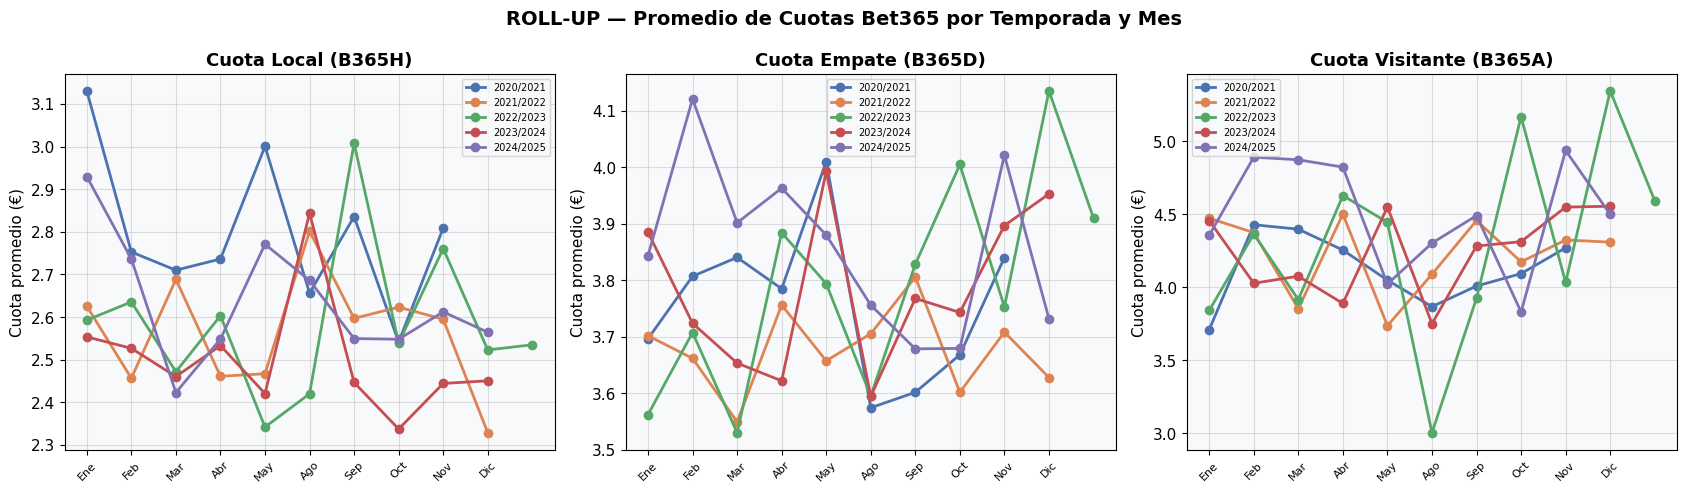

💡 Roll-up: cuotas promedio por mes/temporada. Valores más altos indican mayor incertidumbre percibida por el mercado.


In [11]:
rollup_df = spark.sql('''
    SELECT Temporada, Mes,
           ROUND(AVG(B365H), 4) AS Avg_Local,
           ROUND(AVG(B365D), 4) AS Avg_Empate,
           ROUND(AVG(B365A), 4) AS Avg_Visitante,
           COUNT(*) AS Num_Partidos
    FROM Cubo_Apuestas
    GROUP BY Temporada, Mes
    ORDER BY Temporada, Mes
''')
rollup_df.show(20)

df_rollup  = rollup_df.toPandas()
temporadas = sorted(df_rollup['Temporada'].unique())
MESES = {8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic',
         1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('ROLL-UP — Promedio de Cuotas Bet365 por Temporada y Mes',
             fontsize=14, fontweight='bold')

for ax, col_y, titulo in zip(axes,
    ['Avg_Local','Avg_Empate','Avg_Visitante'],
    ['Cuota Local (B365H)','Cuota Empate (B365D)','Cuota Visitante (B365A)']):
    for i, temp in enumerate(temporadas):
        datos = df_rollup[df_rollup['Temporada'] == temp].sort_values('Mes')
        etiq  = [MESES.get(m, str(m)) for m in datos['Mes']]
        ax.plot(range(len(datos)), datos[col_y], marker='o',
                label=temp, color=COLORES[i % len(COLORES)], linewidth=2)
        ax.set_xticks(range(len(etiq)))
        ax.set_xticklabels(etiq, rotation=45, fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel('Cuota promedio (€)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('💡 Roll-up: cuotas promedio por mes/temporada. Valores más altos indican mayor incertidumbre percibida por el mercado.')

## 🔻 Sección 9: Drill-down — Margen de Error por Equipo

**Drill-down** = descenso en la jerarquía: de temporada global → equipo individual. Mide cuánto se equivoca el mercado en cada equipo específico.

🔻 Top 20 (equipo × temporada) con mayor Margen de Error:
+----------+---------+--------------+--------------+---------+------------+
|    Equipo|Temporada|Partidos_Local|Prob_Implicita|Tasa_Real|Margen_Error|
+----------+---------+--------------+--------------+---------+------------+
|   Almeria|2023/2024|            19|        0.3227|   0.0526|      0.2701|
|     Eibar|2020/2021|            19|        0.3559|   0.1053|      0.2507|
|    Girona|2023/2024|            19|        0.5585|   0.7895|       0.231|
| Vallecano|2023/2024|            19|        0.4192|   0.2105|      0.2086|
|Valladolid|2020/2021|            19|        0.3528|   0.1579|      0.1949|
|Ath Madrid|2023/2024|            19|        0.6493|   0.8421|      0.1928|
|   Almeria|2022/2023|            19|        0.3442|   0.5263|      0.1821|
| Barcelona|2020/2021|            19|        0.7576|   0.5790|      0.1786|
|    Getafe|2024/2025|            19|        0.3855|   0.2105|      0.1749|
|   Osasuna|2022/2023|         

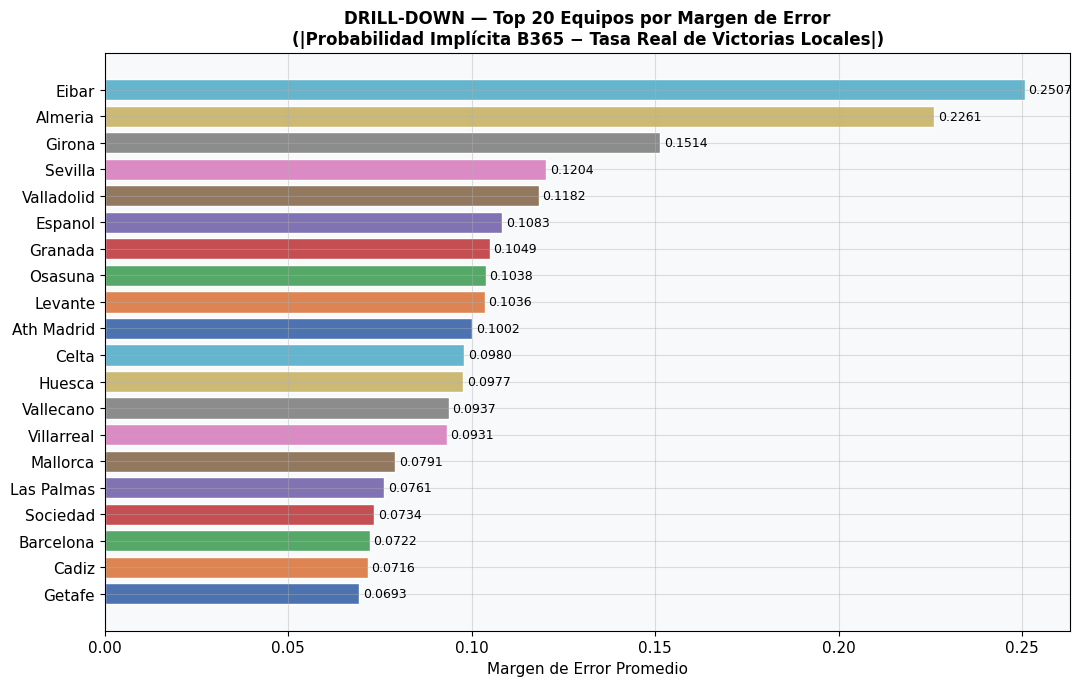

💡 Drill-down: cuanto mayor el margen, mayor la ineficiencia del mercado para ese club.


In [12]:
drill_df = spark.sql('''
    SELECT HomeTeam AS Equipo, Temporada,
           COUNT(*) AS Partidos_Local,
           ROUND(AVG(Prob_H), 4) AS Prob_Implicita,
           ROUND(AVG(CASE WHEN FTR = 'H' THEN 1.0 ELSE 0.0 END), 4) AS Tasa_Real,
           ROUND(ABS(AVG(Prob_H) - AVG(CASE WHEN FTR = 'H' THEN 1.0 ELSE 0.0 END)), 4) AS Margen_Error
    FROM Cubo_Apuestas
    GROUP BY HomeTeam, Temporada
    HAVING COUNT(*) >= 5
    ORDER BY Margen_Error DESC
''')
print('🔻 Top 20 (equipo × temporada) con mayor Margen de Error:')
drill_df.show(20, truncate=22)

df_drill = drill_df.toPandas()
top20 = (df_drill.groupby('Equipo', as_index=False)['Margen_Error']
         .mean().nlargest(20, 'Margen_Error').sort_values('Margen_Error'))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['Equipo'], top20['Margen_Error'],
               color=COLORES[:len(top20)], edgecolor='white')
ax.set_title('DRILL-DOWN — Top 20 Equipos por Margen de Error\n'
             '(|Probabilidad Implícita B365 − Tasa Real de Victorias Locales|)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Margen de Error Promedio')
for bar, val in zip(bars, top20['Margen_Error']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('💡 Drill-down: cuanto mayor el margen, mayor la ineficiencia del mercado para ese club.')

## 🔪 Sección 10: Slice & Dice — Discrepancias Bet365 vs Pinnacle

**Slice** = partidos donde la diferencia entre probabilidades de Bet365 y Pinnacle supera el 10%. **Dice** = comparativa de ambas casas por temporada.

🔪 Partidos con discrepancia > 3%: 79 de 1899 (4.2%)
+----------+----------+-----------+---+---------+----------+--------+-----------+---------+----------+--------+----------+-----------+----------+----------+
|     Fecha|  HomeTeam|   AwayTeam|FTR|Temporada|B365_Local|PS_Local|B365_Empate|PS_Empate|B365_Visit|PS_Visit|Disc_Local|Disc_Empate|Disc_Visit|Disc_Total|
+----------+----------+-----------+---+---------+----------+--------+-----------+---------+----------+--------+----------+-----------+----------+----------+
|2025-05-11|Ath Bilbao|     Alaves|  H|2024/2025|       1.8|    1.89|        2.9|     3.29|       4.5|     4.9|    0.0265|     0.0409|    0.0181|    0.0855|
|2020-09-27|     Cadiz|    Sevilla|  A|2020/2021|       5.0|    5.52|        3.6|     3.38|       1.7|    1.83|    0.0188|     0.0181|    0.0418|    0.0787|
|2025-05-11| Barcelona|Real Madrid|  H|2024/2025|       1.9|    1.96|        3.7|     4.19|       3.2|     3.5|    0.0161|     0.0316|    0.0268|    0.0745|
|2025-

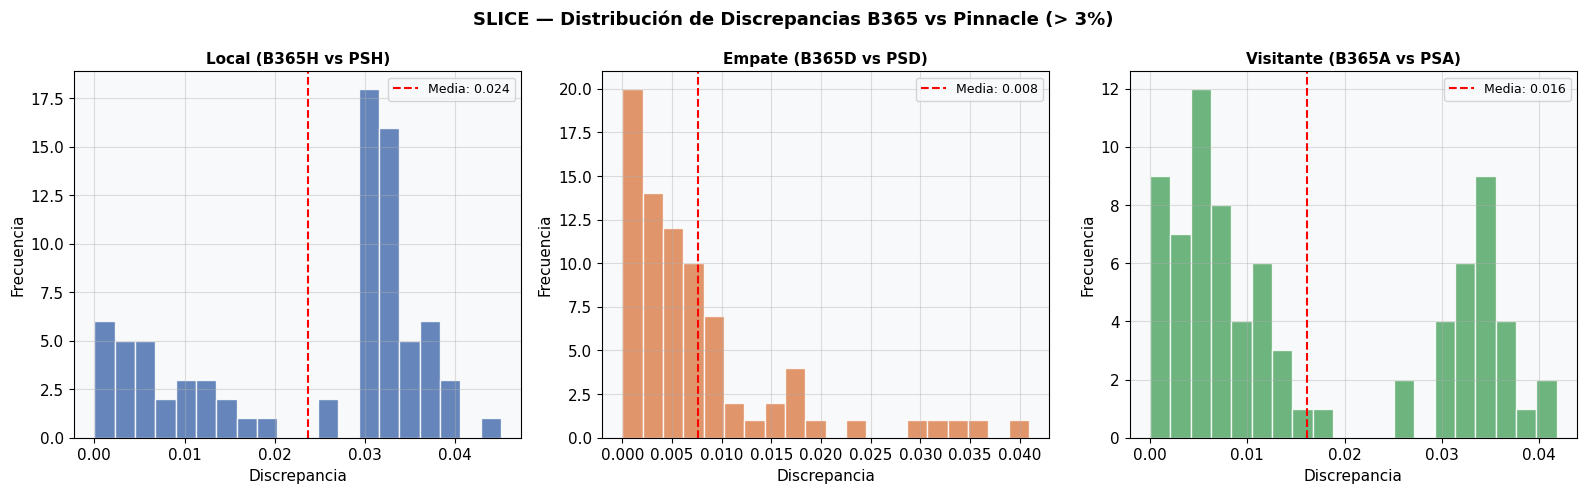

💡 Slice & Dice: aislamos partidos con mayor divergencia entre casas, señal de posible ineficiencia explotable.


In [13]:
slice_df = spark.sql('''
    SELECT Fecha, HomeTeam, AwayTeam, FTR, Temporada,
           ROUND(B365H, 2) AS B365_Local,  ROUND(PSH, 2) AS PS_Local,
           ROUND(B365D, 2) AS B365_Empate, ROUND(PSD, 2) AS PS_Empate,
           ROUND(B365A, 2) AS B365_Visit,  ROUND(PSA, 2) AS PS_Visit,
           ROUND(ABS(1/B365H - 1/PSH), 4) AS Disc_Local,
           ROUND(ABS(1/B365D - 1/PSD), 4) AS Disc_Empate,
           ROUND(ABS(1/B365A - 1/PSA), 4) AS Disc_Visit,
           ROUND(ABS(1/B365H-1/PSH)+ABS(1/B365D-1/PSD)+ABS(1/B365A-1/PSA), 4) AS Disc_Total
    FROM Cubo_Apuestas
    WHERE PSH IS NOT NULL AND PSD IS NOT NULL AND PSA IS NOT NULL
      AND B365H IS NOT NULL AND B365D IS NOT NULL AND B365A IS NOT NULL
      AND (ABS(1/B365H-1/PSH)>0.03 OR ABS(1/B365D-1/PSD)>0.03 OR ABS(1/B365A-1/PSA)>0.03)
    ORDER BY Disc_Total DESC
''')
total_disc = slice_df.count()
total_ps   = spark.sql('''
    SELECT COUNT(*) FROM Cubo_Apuestas WHERE PSH IS NOT NULL AND B365H IS NOT NULL
''').collect()[0][0]
print(f'🔪 Partidos con discrepancia > 3%: {total_disc} de {total_ps} ({100*total_disc/total_ps:.1f}%)')
slice_df.show(10, truncate=16)

dice_df = spark.sql('''
    SELECT Temporada,
           ROUND(AVG(B365H),4) AS Avg_B365_Local,  ROUND(AVG(PSH),4) AS Avg_PS_Local,
           ROUND(AVG(B365D),4) AS Avg_B365_Empate, ROUND(AVG(PSD),4) AS Avg_PS_Empate,
           ROUND(AVG(B365A),4) AS Avg_B365_Visit,  ROUND(AVG(PSA),4) AS Avg_PS_Visit,
           COUNT(*) AS Partidos
    FROM Cubo_Apuestas WHERE PSH IS NOT NULL AND B365H IS NOT NULL
    GROUP BY Temporada ORDER BY Temporada
''')
print('\n🎲 Dice — Comparativa B365 vs Pinnacle por Temporada:')
dice_df.show()

df_slice = slice_df.toPandas()
df_dice  = dice_df.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SLICE — Distribución de Discrepancias B365 vs Pinnacle (> 3%)', fontsize=13, fontweight='bold')
for ax, col, label in zip(axes,
    ['Disc_Local','Disc_Empate','Disc_Visit'],
    ['Local (B365H vs PSH)','Empate (B365D vs PSD)','Visitante (B365A vs PSA)']):
    ax.hist(df_slice[col], bins=20, color=COLORES[['Disc_Local','Disc_Empate','Disc_Visit'].index(col)],
            edgecolor='white', alpha=0.85)
    media = df_slice[col].mean()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.3f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Discrepancia')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('💡 Slice & Dice: aislamos partidos con mayor divergencia entre casas, señal de posible ineficiencia explotable.')

## 🟩 Sección 11: Pivot + Heatmap — Error por Equipo y Temporada

Tabla pivotada que cruza **Equipo × Temporada** mostrando el error medio entre la probabilidad implícita de Bet365 y el resultado real. Visualizada como heatmap.

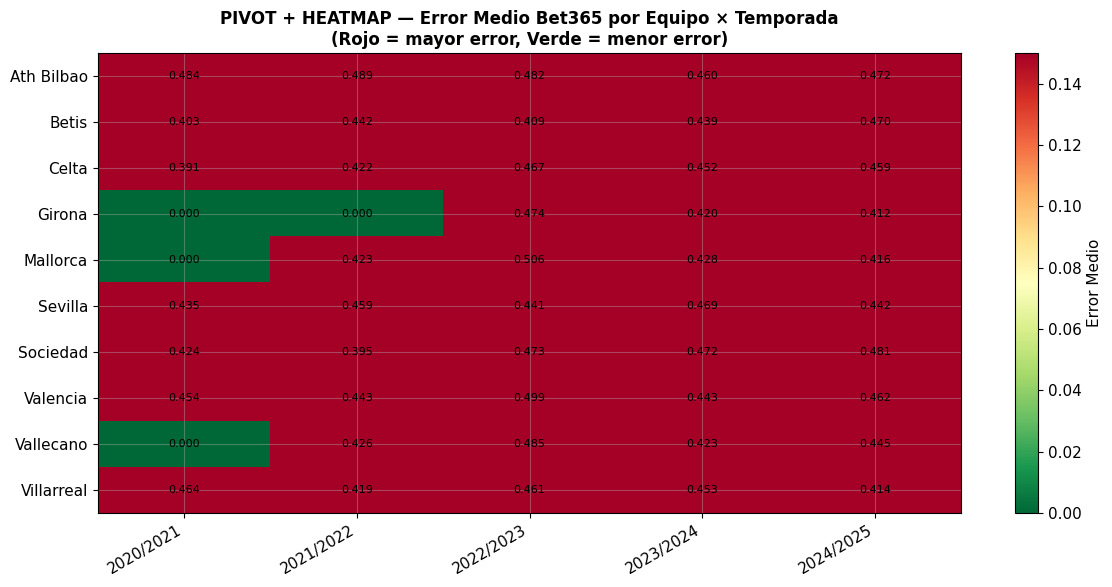

💡 Heatmap: identifica qué equipos y en qué temporadas el mercado se equivocó más sistemáticamente.


In [14]:
pivot_df = spark.sql('''
    SELECT HomeTeam AS Equipo, Temporada,
           ROUND(AVG(ABS(Prob_H - CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END)), 4) AS Error_Medio
    FROM Cubo_Apuestas
    GROUP BY HomeTeam, Temporada
    HAVING COUNT(*) >= 5
''').toPandas()

top10 = (pivot_df.groupby('Equipo')['Error_Medio'].mean()
         .nlargest(10).index.tolist())
pivot_top = pivot_df[pivot_df['Equipo'].isin(top10)]
heatmap_data = pivot_top.pivot_table(index='Equipo', columns='Temporada',
                                      values='Error_Medio', aggfunc='mean', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.15)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(j, i, f'{heatmap_data.values[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Error Medio')
ax.set_title('PIVOT + HEATMAP — Error Medio Bet365 por Equipo × Temporada\n'
             '(Rojo = mayor error, Verde = menor error)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Heatmap: identifica qué equipos y en qué temporadas el mercado se equivocó más sistemáticamente.')

## 📈 Sección 12: Window Functions — Media Móvil del Margen Bet365

Se calcula la **media móvil de 5 partidos** del margen Bet365 usando Window Functions de PySpark, ordenado por fecha dentro de cada temporada. Visualizado como gráfico de área apilada.

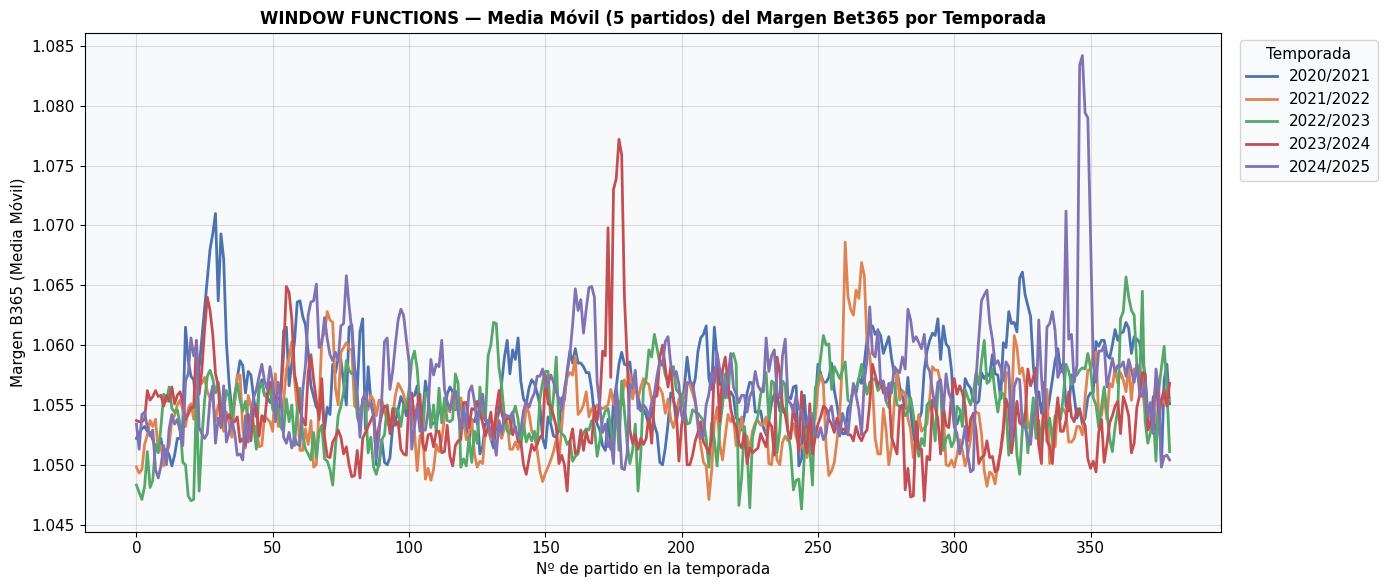

💡 Window Functions: la media móvil suaviza la variación y revela si el overround de Bet365 cambia a lo largo de la temporada.


In [15]:
w = Window.partitionBy('Temporada').orderBy('Fecha').rowsBetween(-2, 2)

df_window = (Fact_Partidos
    .filter(F.col('Margen_B365').isNotNull())
    .withColumn('Media_Movil_Margen', F.round(F.avg('Margen_B365').over(w), 4))
    .select('Fecha','Temporada','Margen_B365','Media_Movil_Margen')
    .orderBy('Temporada','Fecha'))

df_wf = df_window.toPandas()
df_wf['Fecha'] = pd.to_datetime(df_wf['Fecha'])

temporadas_wf = sorted(df_wf['Temporada'].unique())
fig, ax = plt.subplots(figsize=(14, 6))

for i, temp in enumerate(temporadas_wf):
    datos = df_wf[df_wf['Temporada'] == temp].sort_values('Fecha')
    ax.plot(range(len(datos)), datos['Media_Movil_Margen'],
            color=COLORES[i % len(COLORES)], linewidth=2, label=temp)

ax.set_title('WINDOW FUNCTIONS — Media Móvil (5 partidos) del Margen Bet365 por Temporada',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de partido en la temporada')
ax.set_ylabel('Margen B365 (Media Móvil)')
ax.legend(title='Temporada', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()
print('💡 Window Functions: la media móvil suaviza la variación y revela si el overround de Bet365 cambia a lo largo de la temporada.')

## ❓ Sección 13: Preguntas de Negocio (Q1 – Q5)

Cinco preguntas analíticas sobre ineficiencias del mercado de apuestas, cada una respondida con una consulta PySpark y una gráfica.

| # | Pregunta |
|---|----------|
| Q1 | ¿Cuál es la evolución anual del margen (overround) de Bet365 en LaLiga? |
| Q2 | ¿Qué equipos tienen mayor discrepancia sistemática entre la cuota implícita y su rendimiento real como local? |
| Q3 | ¿En qué mes de la temporada el mercado comete más errores de valoración? |
| Q4 | ¿Cuáles son los 10 partidos con mayor discrepancia total entre Bet365 y Pinnacle? |
| Q5 | ¿Existe diferencia entre el margen de error de Bet365 en victorias locales, empates y victorias visitantes? |

Q1 — Margen Bet365 por temporada:
+---------+------------+-------------+--------+
|Temporada|Margen_Medio|Overround_Pct|Partidos|
+---------+------------+-------------+--------+
|2020/2021|      1.0565|         5.65|     380|
|2021/2022|      1.0542|         5.42|     380|
|2022/2023|      1.0544|         5.44|     380|
|2023/2024|       1.054|          5.4|     380|
|2024/2025|      1.0565|         5.65|     380|
+---------+------------+-------------+--------+



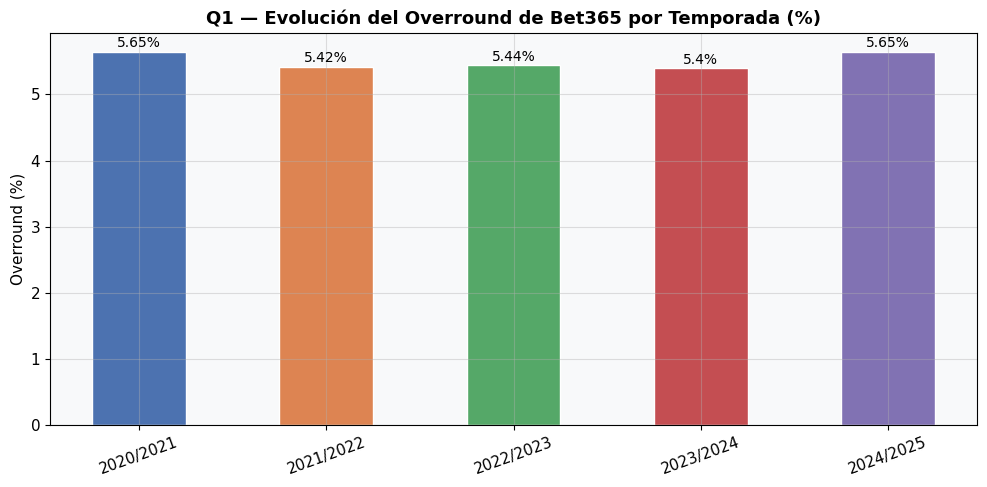

💡 Q1: un overround mayor significa que Bet365 cobra más margen. Valores estables sugieren una política de pricing consistente.


In [16]:
# ── Q1: Evolución anual del margen Bet365 ─────────────────────────────────────
q1 = spark.sql('''
    SELECT Temporada,
           ROUND(AVG(Margen_B365), 4) AS Margen_Medio,
           ROUND((AVG(Margen_B365)-1)*100, 2) AS Overround_Pct,
           COUNT(*) AS Partidos
    FROM Cubo_Apuestas
    GROUP BY Temporada ORDER BY Temporada
''')
print('Q1 — Margen Bet365 por temporada:')
q1.show()

df_q1 = q1.toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_q1['Temporada'], df_q1['Overround_Pct'],
              color=COLORES[:len(df_q1)], edgecolor='white', width=0.5)
ax.set_title('Q1 — Evolución del Overround de Bet365 por Temporada (%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Overround (%)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, df_q1['Overround_Pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print('💡 Q1: un overround mayor significa que Bet365 cobra más margen. Valores estables sugieren una política de pricing consistente.')

Q2 — Equipos con mayor sesgo sistemático:
+----------+--------+--------------------+------------------+-------+
|    Equipo|Partidos|Prob_Implicita_Media|Tasa_Victoria_Real|  Sesgo|
+----------+--------+--------------------+------------------+-------+
|     Eibar|      19|              0.3559|            0.1053| 0.2507|
|   Levante|      38|              0.3667|            0.2632| 0.1035|
|    Huesca|      19|              0.3608|            0.2632| 0.0977|
|Ath Madrid|      95|              0.6497|            0.7368|-0.0871|
|    Girona|      57|               0.478|            0.5614|-0.0834|
|Las Palmas|      38|              0.3393|            0.2632| 0.0762|
|Valladolid|      57|              0.3183|            0.2456| 0.0727|
|Villarreal|      95|              0.5472|            0.4842|  0.063|
| Vallecano|      76|              0.4173|            0.3553|  0.062|
|  Sociedad|      95|              0.5448|            0.4842| 0.0606|
|   Leganes|      19|              0.3202|      

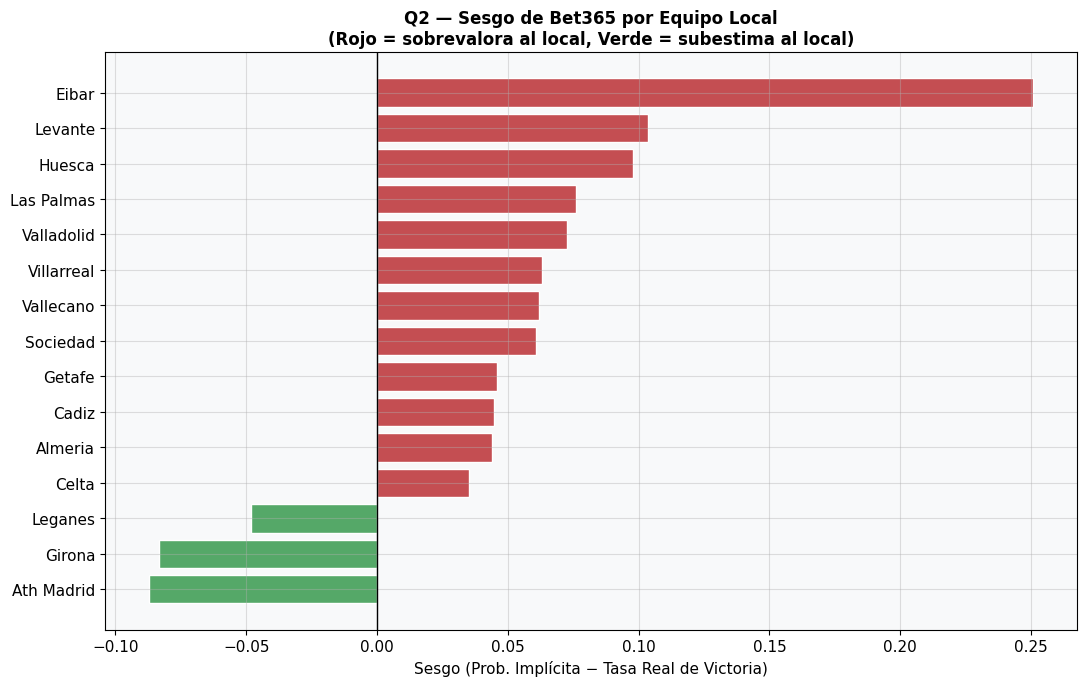

💡 Q2: sesgo positivo = Bet365 sobreestima las chances del local. Sesgo negativo = las subestima. Ambos representan ineficiencias potenciales.


In [17]:
# ── Q2: Equipos con mayor discrepancia sistemática como locales ───────────────
q2 = spark.sql('''
    SELECT HomeTeam AS Equipo,
           COUNT(*) AS Partidos,
           ROUND(AVG(Prob_H), 4) AS Prob_Implicita_Media,
           ROUND(AVG(CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END), 4) AS Tasa_Victoria_Real,
           ROUND(AVG(Prob_H) - AVG(CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END), 4) AS Sesgo
    FROM Cubo_Apuestas
    GROUP BY HomeTeam HAVING COUNT(*) >= 15
    ORDER BY ABS(AVG(Prob_H) - AVG(CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END)) DESC
    LIMIT 15
''')
print('Q2 — Equipos con mayor sesgo sistemático:')
q2.show(truncate=25)

df_q2 = q2.toPandas().sort_values('Sesgo')
colors_q2 = ['#C44E52' if s > 0 else '#55A868' for s in df_q2['Sesgo']]
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(df_q2['Equipo'], df_q2['Sesgo'], color=colors_q2, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Q2 — Sesgo de Bet365 por Equipo Local\n'
             '(Rojo = sobrevalora al local, Verde = subestima al local)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sesgo (Prob. Implícita − Tasa Real de Victoria)')
plt.tight_layout()
plt.show()
print('💡 Q2: sesgo positivo = Bet365 sobreestima las chances del local. Sesgo negativo = las subestima. Ambos representan ineficiencias potenciales.')

Q3 — Error medio por mes:
+---+-----------+-----------+-----------------+--------+
|Mes|Error_Local|Error_Visit|Error_Medio_Total|Partidos|
+---+-----------+-----------+-----------------+--------+
|  1|     0.4203|     0.3791|           0.3997|     191|
|  2|     0.4186|     0.3546|           0.3866|     206|
|  3|     0.4198|     0.3446|           0.3822|     172|
|  4|     0.4421|     0.3851|           0.4136|     227|
|  5|     0.4241|     0.3666|           0.3954|     246|
|  6|     0.4689|     0.3493|           0.4091|      10|
|  8|     0.3992|       0.39|           0.3946|     124|
|  9|     0.4075|     0.3543|           0.3809|     189|
| 10|     0.4442|     0.3849|           0.4146|     208|
| 11|     0.4224|     0.3504|           0.3864|     149|
| 12|     0.4335|     0.3593|           0.3964|     178|
+---+-----------+-----------+-----------------+--------+



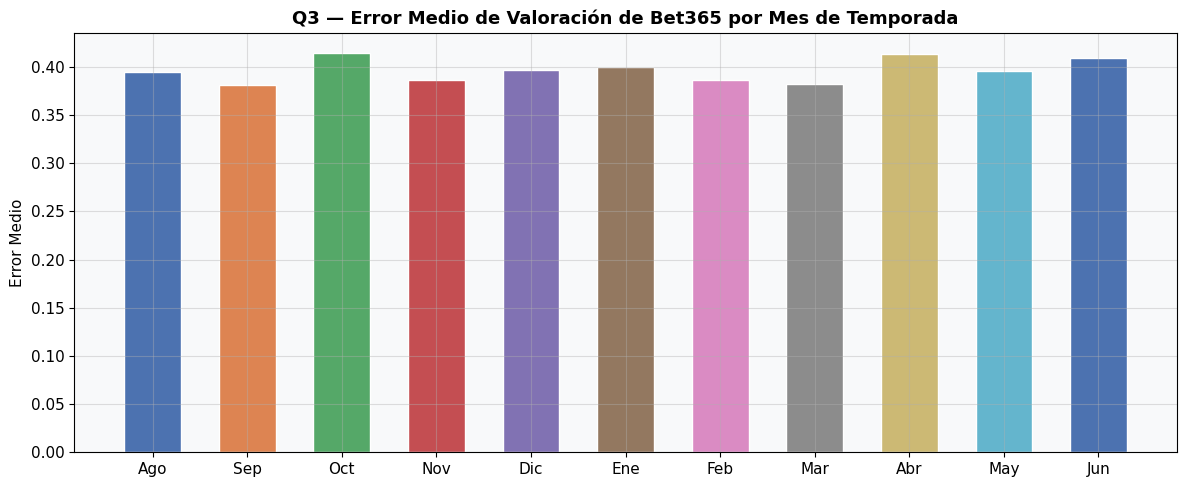

💡 Q3: los meses con mayor error indican mayor incertidumbre estructural, posiblemente por lesiones, inicio de temporada o final de liga.


In [18]:
# ── Q3: Mes con mayor error de valoración ─────────────────────────────────────
q3 = spark.sql('''
    SELECT Mes,
           ROUND(AVG(ABS(Prob_H - CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END)), 4) AS Error_Local,
           ROUND(AVG(ABS(Prob_A - CASE WHEN FTR='A' THEN 1.0 ELSE 0.0 END)), 4) AS Error_Visit,
           ROUND(AVG(ABS(Prob_H - CASE WHEN FTR='H' THEN 1.0 ELSE 0.0 END) +
                    ABS(Prob_A - CASE WHEN FTR='A' THEN 1.0 ELSE 0.0 END)) / 2, 4) AS Error_Medio_Total,
           COUNT(*) AS Partidos
    FROM Cubo_Apuestas
    GROUP BY Mes ORDER BY Mes
''')
print('Q3 — Error medio por mes:')
q3.show()

df_q3 = q3.toPandas()
df_q3['Mes_Nombre'] = df_q3['Mes'].map(MESES)
orden_meses = [8,9,10,11,12,1,2,3,4,5,6]
df_q3 = df_q3.set_index('Mes').reindex(orden_meses).reset_index()
df_q3['Mes_Nombre'] = df_q3['Mes'].map(MESES)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(df_q3))
ax.bar(x, df_q3['Error_Medio_Total'], color=COLORES[:len(df_q3)], edgecolor='white', width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(df_q3['Mes_Nombre'])
ax.set_title('Q3 — Error Medio de Valoración de Bet365 por Mes de Temporada',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Error Medio')
plt.tight_layout()
plt.show()
print('💡 Q3: los meses con mayor error indican mayor incertidumbre estructural, posiblemente por lesiones, inicio de temporada o final de liga.')

Q4 — Top 10 partidos con mayor discrepancia B365 vs Pinnacle:
+----------+----------+-----------+---+---------+------+----+------+-----+----------+
|     Fecha|  HomeTeam|   AwayTeam|FTR|Temporada|B365_L|PS_L|B365_V| PS_V|Disc_Total|
+----------+----------+-----------+---+---------+------+----+------+-----+----------+
|2025-05-11|Ath Bilbao|     Alaves|  H|2024/2025|   1.8|1.89|   4.5|  4.9|    0.0855|
|2020-09-27|     Cadiz|    Sevilla|  A|2020/2021|   5.0|5.52|   1.7| 1.83|    0.0787|
|2025-05-11| Barcelona|Real Madrid|  H|2024/2025|   1.9|1.96|   3.2|  3.5|    0.0745|
|2025-05-15|    Getafe| Ath Bilbao|  A|2024/2025|   3.2|3.65|  2.63| 2.69|     0.071|
|2021-04-25|Ath Bilbao| Ath Madrid|  H|2020/2021|   4.0|4.46|  1.85| 1.98|    0.0705|
|2024-10-27|    Getafe|   Valencia|  D|2024/2025|   2.1|2.19|   3.8| 4.28|    0.0701|
|2023-12-21|     Cadiz|   Sociedad|  D|2023/2024|  4.75| 4.8|  1.75| 1.87|     0.069|
|2022-01-23| Vallecano| Ath Bilbao|  A|2021/2022|  2.75|2.96|   2.8| 2.96|    

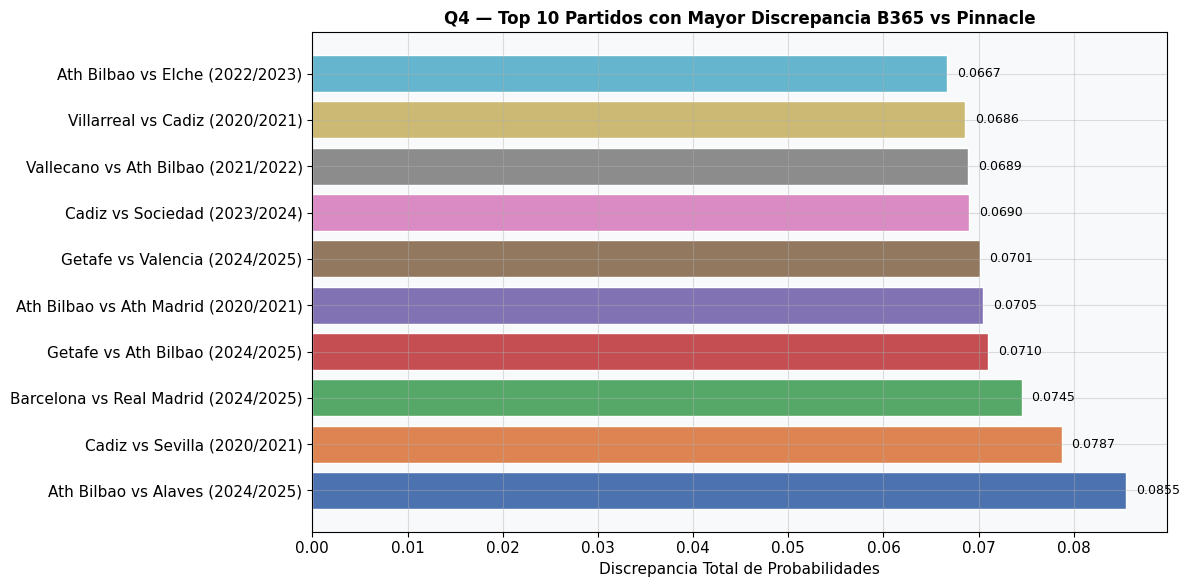

💡 Q4: estos son los partidos donde las dos casas más eficientes del mercado discreparon más. Señal clara de incertidumbre extrema.


In [19]:
# ── Q4: Top 10 partidos con mayor discrepancia B365 vs Pinnacle ───────────────
q4 = spark.sql('''
    SELECT Fecha, HomeTeam, AwayTeam, FTR, Temporada,
           ROUND(B365H,2) AS B365_L, ROUND(PSH,2) AS PS_L,
           ROUND(B365A,2) AS B365_V, ROUND(PSA,2) AS PS_V,
           ROUND(ABS(1/B365H-1/PSH)+ABS(1/B365D-1/PSD)+ABS(1/B365A-1/PSA), 4) AS Disc_Total
    FROM Cubo_Apuestas
    WHERE PSH IS NOT NULL AND B365H IS NOT NULL
    ORDER BY Disc_Total DESC
    LIMIT 10
''')
print('Q4 — Top 10 partidos con mayor discrepancia B365 vs Pinnacle:')
q4.show(truncate=20)

df_q4 = q4.toPandas()
df_q4['Partido'] = df_q4['HomeTeam'] + ' vs ' + df_q4['AwayTeam'] + ' (' + df_q4['Temporada'] + ')'

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_q4['Partido'], df_q4['Disc_Total'],
               color=COLORES[:10], edgecolor='white')
ax.set_title('Q4 — Top 10 Partidos con Mayor Discrepancia B365 vs Pinnacle',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Discrepancia Total de Probabilidades')
for bar, val in zip(bars, df_q4['Disc_Total']):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('💡 Q4: estos son los partidos donde las dos casas más eficientes del mercado discreparon más. Señal clara de incertidumbre extrema.')

Q5 — Error de Bet365 por tipo de resultado:
+---------+----------------+-----------------+----------------+--------+
|Resultado|Error_Prob_Local|Error_Prob_Empate|Error_Prob_Visit|Partidos|
+---------+----------------+-----------------+----------------+--------+
|        A|           0.362|           0.2832|          0.5901|     546|
|        D|          0.4391|           0.7114|          0.3273|     513|
|        H|          0.4568|           0.2655|          0.2465|     841|
+---------+----------------+-----------------+----------------+--------+



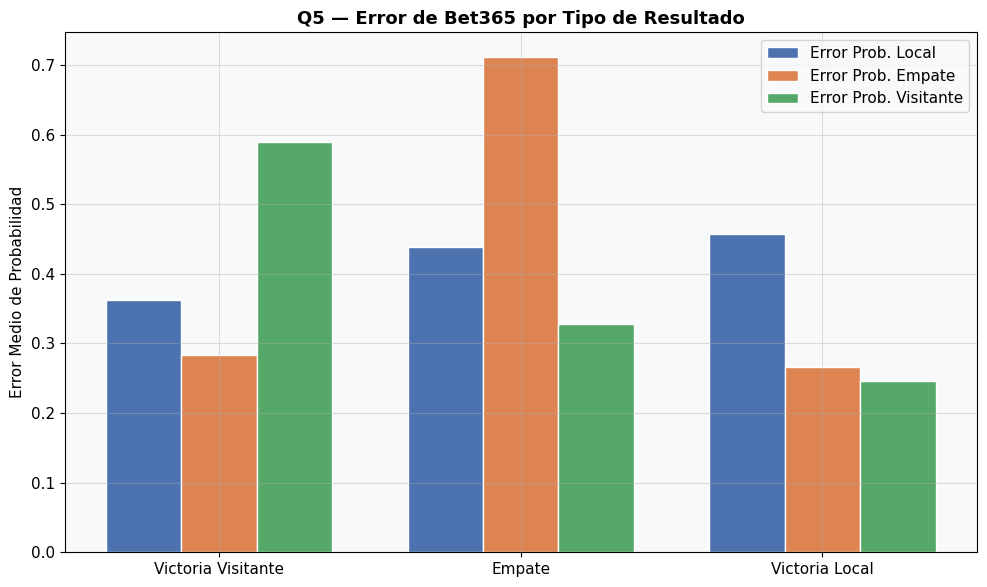

💡 Q5: si el error es mayor en empates, significa que el mercado tiene más dificultad valorando esa opción — conocida ineficiencia estructural del betting.


In [20]:
# ── Q5: Error de Bet365 por tipo de resultado (H / D / A) ─────────────────────
q5 = spark.sql('''
    SELECT FTR AS Resultado,
           ROUND(AVG(CASE WHEN FTR='H' THEN ABS(Prob_H-1) ELSE ABS(Prob_H-0) END), 4) AS Error_Prob_Local,
           ROUND(AVG(CASE WHEN FTR='D' THEN ABS(Prob_D-1) ELSE ABS(Prob_D-0) END), 4) AS Error_Prob_Empate,
           ROUND(AVG(CASE WHEN FTR='A' THEN ABS(Prob_A-1) ELSE ABS(Prob_A-0) END), 4) AS Error_Prob_Visit,
           COUNT(*) AS Partidos
    FROM Cubo_Apuestas
    GROUP BY FTR ORDER BY FTR
''')
print('Q5 — Error de Bet365 por tipo de resultado:')
q5.show()

df_q5 = q5.toPandas()
etiquetas = {'H': 'Victoria Local', 'D': 'Empate', 'A': 'Victoria Visitante'}
df_q5['Resultado_Nombre'] = df_q5['Resultado'].map(etiquetas)

x = np.arange(len(df_q5))
ancho = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - ancho, df_q5['Error_Prob_Local'],   ancho, label='Error Prob. Local',   color=COLORES[0], edgecolor='white')
ax.bar(x,         df_q5['Error_Prob_Empate'],  ancho, label='Error Prob. Empate',  color=COLORES[1], edgecolor='white')
ax.bar(x + ancho, df_q5['Error_Prob_Visit'],   ancho, label='Error Prob. Visitante', color=COLORES[2], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_q5['Resultado_Nombre'])
ax.set_title('Q5 — Error de Bet365 por Tipo de Resultado',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Error Medio de Probabilidad')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Q5: si el error es mayor en empates, significa que el mercado tiene más dificultad valorando esa opción — conocida ineficiencia estructural del betting.')

## 📋 Sección 14: Resumen Final

In [21]:
print('=' * 65)
print('📊  RESUMEN DEL ANÁLISIS DE INEFICIENCIAS EN LALIGA (PySpark)')
print('=' * 65)

total_partidos = Cubo_Apuestas.count()
total_temp     = Cubo_Apuestas.select('Temporada').distinct().count()
total_equipos  = Dim_Equipo.count()
margen_avg     = Cubo_Apuestas.agg(F.round(F.avg('Margen_B365'), 4)).collect()[0][0]
overround_pct  = round((margen_avg - 1) * 100, 2)

print(f'\n📅 Temporadas analizadas  : {total_temp}')
print(f'⚽ Total partidos          : {total_partidos}')
print(f'🏟️  Equipos únicos          : {total_equipos}')
print(f'💰 Margen promedio B365    : {margen_avg}  (+{overround_pct}% overround)')
print(f'\n📐 Modelo Estrella:')
print(f'   Dim_Equipo     → {Dim_Equipo.count()} registros')
print(f'   Dim_Tiempo     → {Dim_Tiempo.count()} registros')
print(f'   Fact_Partidos  → {Fact_Partidos.count()} registros')
print(f'\n🗄️  Base de datos SQLite: laliga_apuestas.db')
print(f'   Tablas: dim_equipo, dim_tiempo, fact_partidos')
print(f'\n🎯 Operaciones OLAP ejecutadas:')
print('   ✅ Roll-up         : cuotas promedio por Temporada × Mes')
print('   ✅ Drill-down      : Margen de Error por Equipo')
print('   ✅ Slice & Dice    : discrepancias B365 vs Pinnacle')
print('   ✅ Pivot + Heatmap : error por Equipo × Temporada')
print('   ✅ Window Functions: media móvil del margen B365')
print(f'\n❓ Preguntas de negocio respondidas: Q1 – Q5')
print(f'\n🔗 Repositorio: https://github.com/RicardoSada/bigdata-apuestas-ufv')

📊  RESUMEN DEL ANÁLISIS DE INEFICIENCIAS EN LALIGA (PySpark)

📅 Temporadas analizadas  : 5
⚽ Total partidos          : 1900
🏟️  Equipos únicos          : 27
💰 Margen promedio B365    : 1.0552  (+5.52% overround)

📐 Modelo Estrella:
   Dim_Equipo     → 27 registros
   Dim_Tiempo     → 696 registros
   Fact_Partidos  → 1900 registros

🗄️  Base de datos SQLite: laliga_apuestas.db
   Tablas: dim_equipo, dim_tiempo, fact_partidos

🎯 Operaciones OLAP ejecutadas:
   ✅ Roll-up         : cuotas promedio por Temporada × Mes
   ✅ Drill-down      : Margen de Error por Equipo
   ✅ Slice & Dice    : discrepancias B365 vs Pinnacle
   ✅ Pivot + Heatmap : error por Equipo × Temporada
   ✅ Window Functions: media móvil del margen B365

❓ Preguntas de negocio respondidas: Q1 – Q5

🔗 Repositorio: https://github.com/RicardoSada/bigdata-apuestas-ufv
